In [1]:
!pip install xgboost lightgbm shap -q

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab/placement_dataset.csv')
print(df.head())

   CGPA     IQ  Aptitude_Score  Communication_Skill  Internships Branch Placed
0  8.00   81.0            89.0                    1            1   MECH     No
1  7.36  105.0            74.0                    5            3  CIVIL    Yes
2  8.15   96.0            62.0                    6            1     IT     No
3  9.02  119.0            56.0                    6            2    CSE     No
4   NaN    NaN             NaN                    3            3    CSE    Yes


In [4]:
from sklearn.preprocessing import LabelEncoder

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col])

In [5]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, pred_xgb))

XGBoost Accuracy: 0.425


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [19:48:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [8]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier()

lgbm.fit(X_train, y_train)

pred_lgbm = lgbm.predict(X_test)

print("LightGBM Accuracy:",
      accuracy_score(y_test, pred_lgbm))

[LightGBM] [Info] Number of positive: 94, number of negative: 66
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000176 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 142
[LightGBM] [Info] Number of data points in the train set: 160, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.587500 -> initscore=0.353640
[LightGBM] [Info] Start training from score 0.353640
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

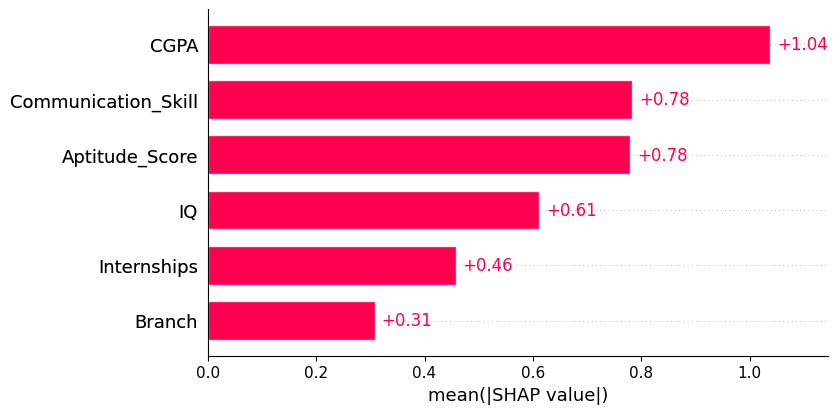

In [9]:
import shap

explainer = shap.Explainer(xgb)

shap_values = explainer(X_test)

shap.plots.bar(shap_values)

In [10]:
print("XGBoost Accuracy:",
      accuracy_score(y_test, pred_xgb))

print("LightGBM Accuracy:",
      accuracy_score(y_test, pred_lgbm))

XGBoost Accuracy: 0.425
LightGBM Accuracy: 0.525
